# **TPO Data Programme**

TPOs in Dundee Data

Visualisation Overview

Data used for this analysis: TPODataDundee.csv

## **Aim**
### **Load and Validate Data**
Implement a load_data() function that reads the CSV and checks for missing or malformed entries in key columns such as TPOREFNO, ADDRESS1, ADDRESS3,
and Year.

-	Inspect the dataset for duplicate entries or inconsistent formatting.

### **Clean Data**

Write a clean_data() function to:
- Standardise categorical columns (ADDRESS3, TreeSpecies) for consistency.
- Convert numeric or date-like fields (Year, TreeAge) to correct types.
- Handle missing values appropriately, either by removing rows or imputing defaults.

### **Exploratory Data Visualisation**

Create a generate_visualisations() function that produces at least three different types of plots:

- A time-series line chart showing the number of TPOs issued per year.
- A bar chart comparing TPO counts across areas (ADDRESS3).
- A histogram or boxplot showing the distribution of tree ages or years of protection.

Include appropriate titles, axis labels, legends, colors, and markers to make insights clear.

### **Spatial and Categorical Insights**

Use the visualisations to identify patterns such as:

- Areas with the highest number of TPOs.
- Years with spikes in TPO issuance.
- Variation in tree ages or protection periods.

Generate a brief summary report interpreting these trends.

### **Save Outputs**

- Save all generated plots as PDF and JPEG files.
- Save the cleaned dataset as cleanedTPODataDundee.csv.


In [1]:
#Import Python libraries
import pandas as pd
import numpy as np
import logging
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

In [3]:
#Start logging
logging.basicConfig(level = logging.INFO)

In [4]:
#Define functions


#Function to load data
def load_data(csv_name : str = 'TPODundeeData'):
  '''
  Load dataset.

  Parameters:
    csv_name(str) : Name of the csv file to load.

  Returns:
    pd.DataFrame : DataFrame of the csv dataset.
  '''

  #Return data
  logging.info('Data loaded')
  return pd.read_csv(f'{csv_name}.csv')


#Function to clean and validate data
def clean_data(data_df : pd.DataFrame):
  '''
  Clean dataset.

  Parameters:
    data_df(pd.DataFrame) : DataFrame to clean.

  Returns:
    pd.DataFrame : Cleaned DataFrame.
  '''

  #To work with the copy of the dataset
  data_df = data_df.copy()

  #Checking missing values in the DataFrame, drop rows with missing values
  for column in data_df.columns:
    if data_df[column].isna().sum() != 0:
      data_df.dropna(subset = [column], axis = 0, inplace = True)

  #Check duplicates in the DataFrame, drop rows with duplicate values
  if data_df.duplicated().sum() != 0:
    data_df.drop_duplicates()

  #Convert all object datatype: ADDRESS1, ADDRESS2, ADDRESS3, TPOREFNO to string
  for column in data_df.columns:
    if data_df[column].dtype == 'object':
      data_df[column] = data_df[column].astype('string')
    else:
      data_df[column] = data_df[column].astype('int64')

  #Standardize capitalization, and removing extra spaces
  for column in data_df.columns:
    if data_df[column].dtype == 'string':
      data_df[column] = data_df[column].str.strip().str.title()

  #Convert some object datatype: TPOREFNO
  #Create new column and extract 2-digit year
  data_df['Year_2digit'] = data_df['TPOREFNO'].str.split('/').str[1]

  #Check missing values and drop: TPOREFNO
  if data_df['Year_2digit'].isna().sum() != 0:
    data_df.dropna(subset = ['Year_2digit'], axis = 0, inplace = True)

  #Convert column to integer: TPOREFNO
  y = data_df['Year_2digit'] = data_df['Year_2digit'].astype('int64')

  #Convert column to four digit year: TPOREFNO
  data_df['Year'] = np.where(y <= 26, 2000 + y, 1900 + y)

  #Do Sanity check
  print(data_df['Year'].agg(['min', 'max']))

  #Return data
  logging.info('Data cleaned')
  return data_df


#Function to visualize cleaned data
def generate_visualisations(data_df : pd.DataFrame):
  '''
  Generate visualisations

  Parameterrs:
    data_df(pd.DataFrame) : DataFrame to visualise.

  Returns:
    None
  '''

  #To work with the copy of the dataset
  data_df = data_df.copy()

  #Creating a filtered DataFrame based on value counts of ADDRESS3, if value counts larger than 1
  filtered_df = data_df[data_df['ADDRESS3'].map(data_df['ADDRESS3'].value_counts()) > 1]

  #Simple Automation - same plot, two DataFrame - Line Graph
  dfs = {'Original data' : data_df, 'Filtered data' : filtered_df}

  for key, df in dfs.items():
    plt.figure(figsize = (10,5))
    plt.plot(df['Year'].value_counts().sort_index().index, df['Year'].value_counts().sort_index().values, color = 'blue', linestyle = '-', marker = 'o', label = f'TPOs per Year')
    plt.title(f'TPOs in Dundee over Years - {key}', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Year', fontsize = 12)
    plt.ylabel('Number of TPOs', fontsize = 12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    filename_pdf = f'TPO_trends_{key}.pdf'
    plt.savefig(filename_pdf)
    filename_jpg = f'TPO_trend_{key}.jpg'
    plt.savefig(filename_jpg, dpi = 300)
    plt.show()
    plt.close()

  #Simple Automation - Same plot, two DataFrame - Bar Chart
  dfs = {'Original Data' : data_df, 'Filtered Data' : filtered_df}

  for key, df in dfs.items():
    plt.figure(figsize = (10, 5))
    sns.barplot(x = df['ADDRESS3'].value_counts().values, y = df['ADDRESS3'].value_counts().index, palette = 'muted')
    plt.title(f'Number of TPOs by Area - {key}', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Number of TPOs', fontsize = 12)
    plt.ylabel('Area (ADDRESS3)', fontsize = 12)
    plt.tight_layout()
    filename_pdf = f'TPO_area_bar_{key}.pdf'
    plt.savefig(filename_pdf)
    filename_jpg = f'TPO_area_bar_{key}.jpg'
    plt.savefig(filename_jpg, dpi = 300)
    plt.show()
    plt.close()

  #Simple Automation - Same plot, Two DataFames - Boxplot
  dfs = {'Original Data' : data_df, 'Filtered Data' : filtered_df}

  for key, df in dfs.items():
    plt.figure(figsize = (10, 5))
    sns.boxplot(x = 'Year', y = 'ADDRESS3', data = df, palette = 'pastel')
    plt.title(f'Year Distribution of TPOs per Area - {key}', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Year', fontsize = 12)
    plt.ylabel('Area (ADDRESS3)', fontsize = 12)
    plt.tight_layout()
    filename_pdf = f'TPO_area_box_{key}.pdf'
    plt.savefig(filename_pdf)
    filename_jpg = f'TPO_are_box_{key}.jpg'
    plt.savefig(filename_jpg, dpi = 300)
    plt.show()
    plt.close()

  #Return data
  logging.info('Graphs created')
  return None


#Save data
def save_data(data_df : pd.DataFrame, filepath : str):
  '''
  Save dataset.

  Parameters:
    data_df(pd.DataFrame) : DataFrame to save.
    filepath(str) : Path to save the file.

  Returns:
    None
  '''

  data_df.to_csv(filepath, index = False)
  logging.info('Data saved')


In [5]:
#Main
def main():
  data_df = load_data()
  data_df = clean_data(data_df)
  save_data(data_df, 'cleanedTPODataDundee.csv')
  generate_visualisations(data_df)



min    1982
max    2023
Name: Year, dtype: int64


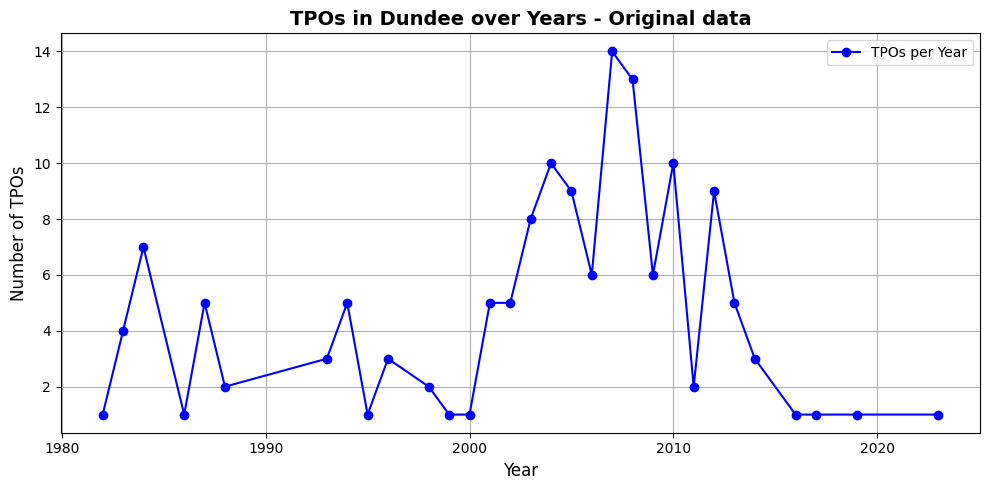

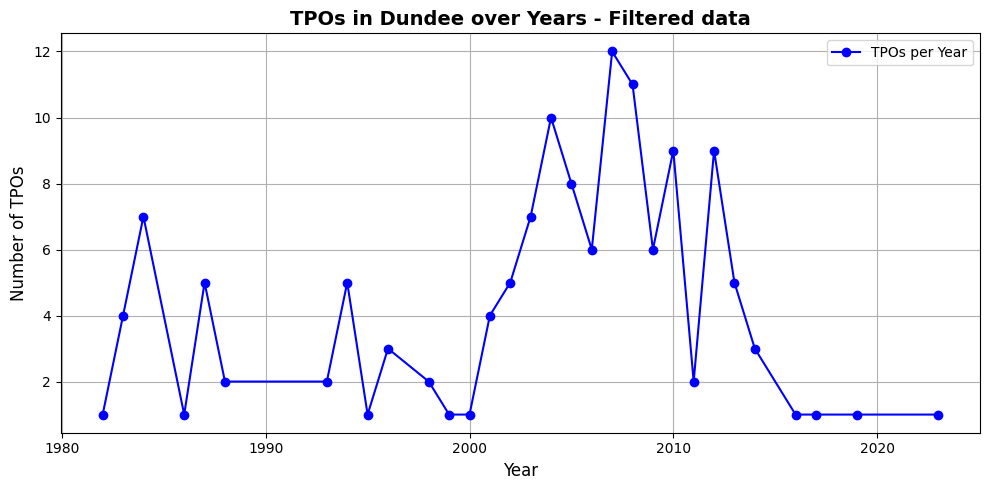

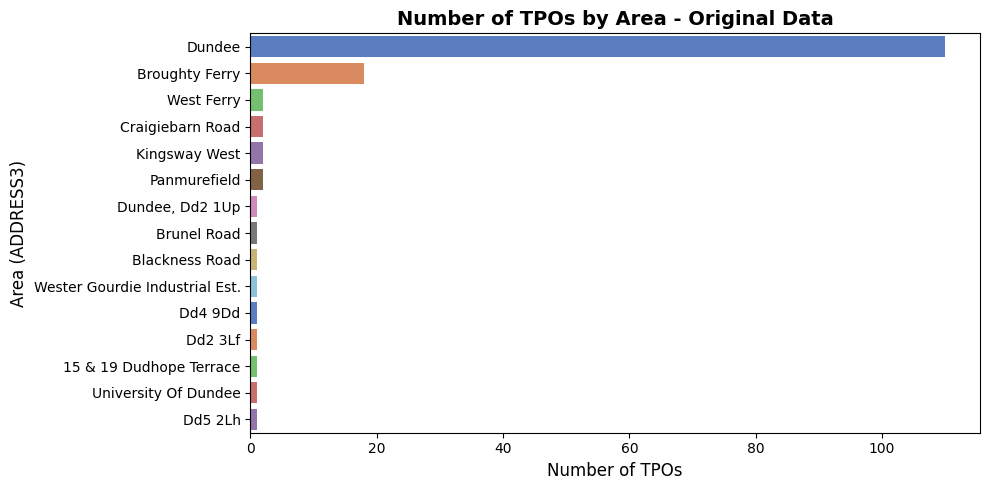

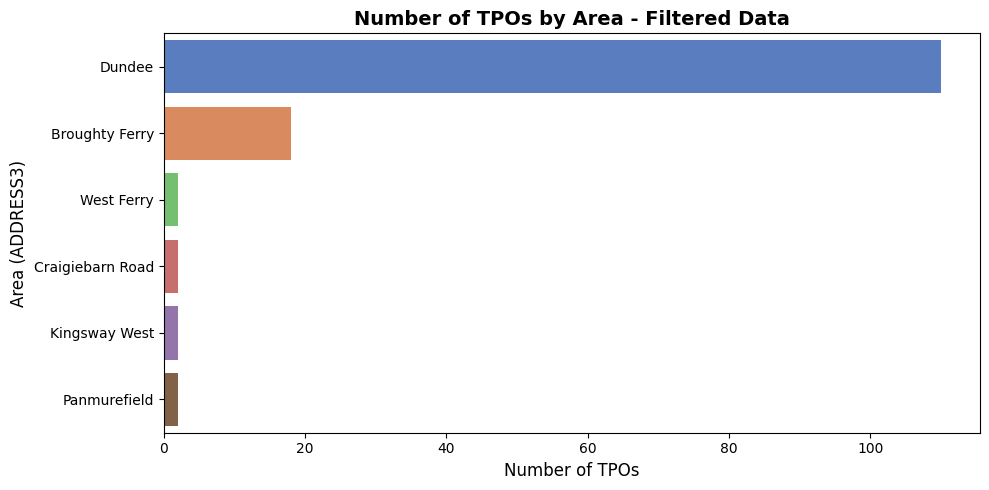

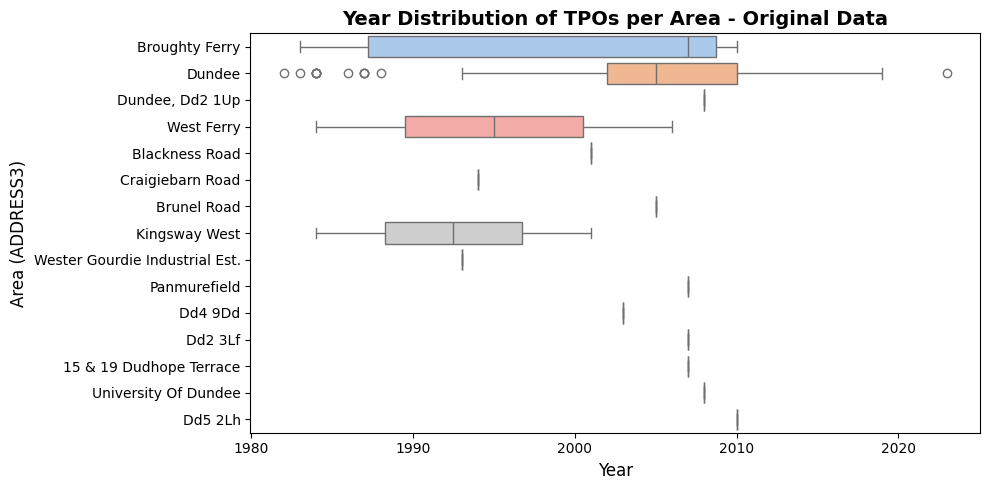

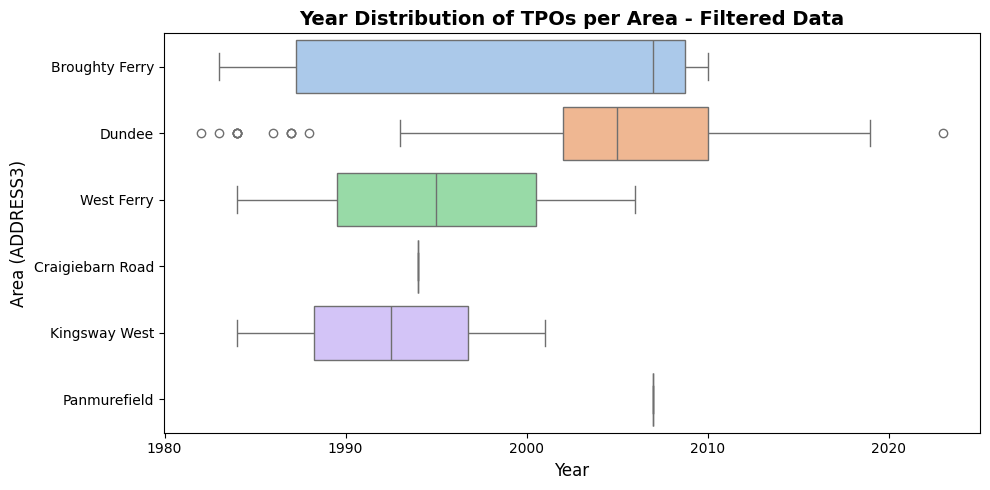

In [6]:
#Run program
main()